<a href="https://colab.research.google.com/github/Vishnu252005/3js_Multiple_window/blob/main/smart_build_energy_efficiency.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Explanation of Code and Algorithms

This notebook demonstrates a machine learning workflow for classifying building energy efficiency.

**1. Data Loading and Initial Inspection:**
- The code starts by loading the Energy Efficiency Dataset from a UCI repository URL into a pandas DataFrame.
- `df.head()` displays the first few rows of the DataFrame to give an initial look at the data structure and values.

**2. Data Preprocessing and Scaling:**
- A binary classification target 'Efficiency' is created based on whether the heating load ('Y1') is above or below its median. This transforms the problem into a binary classification task (High vs. Low Efficiency).
- The features (columns X1 to X8) are separated from the target variable.
- `StandardScaler` is used to scale the features. This is important because some machine learning algorithms (like SVM and ANN) are sensitive to the scale of the input features. Scaling ensures that all features contribute equally to the model training process.

**3. Model Definition and Cross-Validation Setup:**
- Three different machine learning models are defined:
    - **Support Vector Machine (SVM):** A powerful linear or non-linear classifier that finds a hyperplane to separate data points. `SVC` from scikit-learn is used with `probability=True` to enable probability predictions needed for ROC curves.
    - **Decision Tree:** A tree-like model that makes decisions based on splitting the data at each node according to feature values. `DecisionTreeClassifier` from scikit-learn is used with a fixed `random_state` for reproducibility.
    - **Artificial Neural Network (ANN):** A model inspired by the human brain, consisting of interconnected layers of neurons. `MLPClassifier` (Multi-layer Perceptron) from scikit-learn is used with `max_iter=1000` to set the maximum number of iterations for the solver.
- `StratifiedKFold` is set up for 10-fold cross-validation. Stratified K-Fold ensures that each fold has the same proportion of the target variable as the original dataset, which is important for evaluating classification models, especially with imbalanced datasets. `shuffle=True` randomizes the data before splitting, and `random_state=42` ensures the splits are the same each time the code is run.

**4. Model Training and Evaluation with Cross-Validation:**
- The code defines a dictionary `scoring` with several evaluation metrics: Precision, Recall, F1-score, and ROC-AUC. `make_scorer` is used to create callable scoring functions for Precision, Recall, and F1-score.
- A loop iterates through each defined model:
    - `cross_validate` performs the 10-fold cross-validation for the current model using the specified scoring metrics and the `cv` object.
    - The mean score for each metric across the 10 folds is printed for each model. This provides an estimate of how well each model is expected to perform on unseen data.

**5. Visualizations: Confusion Matrices and ROC Curves:**
- This section aims to visualize the performance of each model:
    - **Confusion Matrix:** `cross_val_predict` is used to get predictions for each data point when it is in the test fold during cross-validation. The `confusion_matrix` is then computed to show the counts of true positives, true negatives, false positives, and false negatives. `ConfusionMatrixDisplay` is used to plot the confusion matrix.
    - **ROC Curve:** For models that can predict probabilities (`predict_proba`), the ROC curve is plotted. The ROC curve shows the trade-off between the true positive rate (Recall) and the false positive rate at different probability thresholds. The Area Under the ROC Curve (ROC-AUC) provides a single metric to summarize the overall performance. `roc_curve` computes the points for the curve, and `RocCurveDisplay` plots it.

**6. Feature Importance Analysis (Decision Tree):**
- A Decision Tree model is trained on the entire scaled dataset.
- `feature_importances_` attribute of the trained Decision Tree model is used to get the importance of each feature in making predictions.
- The feature importances are then visualized as a bar plot, showing which features the Decision Tree considered most important for classifying energy efficiency.

In summary, the notebook loads and preprocesses data, defines and evaluates three classification models using cross-validation and various performance metrics, and visualizes the results. The feature importance analysis provides insights into the Decision Tree model's decision-making process.

In [ ]:
import pandas as pd

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00242/ENB2012_data.xlsx"
df = pd.read_excel(url)
df.head()


,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


## Data Preprocessing and Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

# Binary classification: High vs Low Heating Load
df['Efficiency'] = df['Y1'].apply(lambda x: 1 if x > df['Y1'].median() else 0)
X = df.iloc[:, :8]
y = df['Efficiency']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Model Definition and Cross-Validation Setup

In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier

models = {
    "SVM": SVC(probability=True),
    "Decision Tree": DecisionTreeClassifier(),
    "ANN": MLPClassifier(max_iter=1000)
}

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

## Model Training and Evaluation with Cross-Validation

In [ ]:
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score, roc_auc_score

scoring = {
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score),
    'f1': make_scorer(f1_score),
    'roc_auc': 'roc_auc'
}

for name, model in models.items():
    scores = cross_validate(model, X_scaled, y, cv=cv, scoring=scoring)
    print(f"\n{name} Performance:")
    for metric in scoring:
        print(f"{metric}: {scores['test_' + metric].mean():.3f}")


SVM Performance:
precision: 0.977
recall: 0.977
f1: 0.977
roc_auc: 0.996

Decision Tree Performance:
precision: 0.990
recall: 0.992
f1: 0.991
roc_auc: 0.991

ANN Performance:
precision: 0.982
recall: 0.969
f1: 0.975
roc_auc: 0.998


## Visualizations: Confusion Matrices and ROC Curves


--- SVM ---


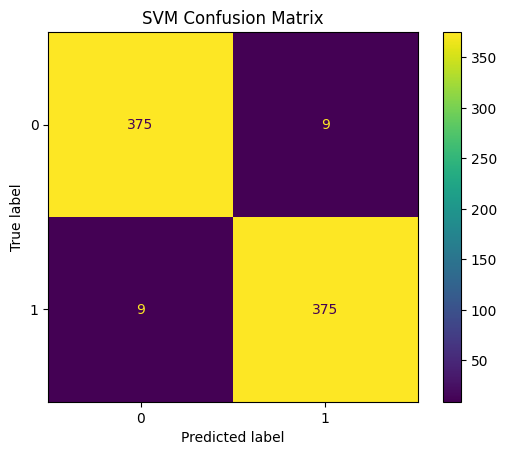

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_plot/roc_curve.py:189: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  self.ax_.legend(loc="lower right")


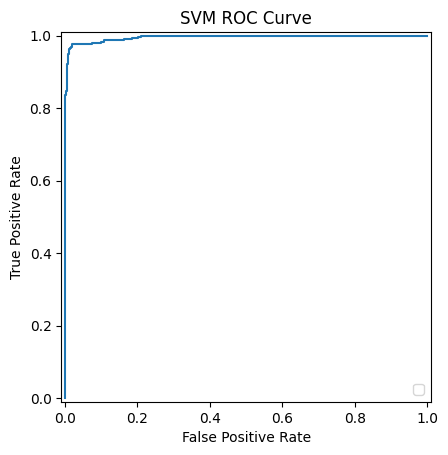


--- Decision Tree ---


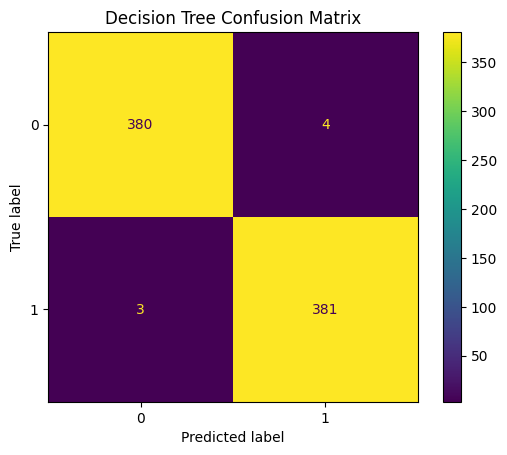

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_plot/roc_curve.py:189: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  self.ax_.legend(loc="lower right")


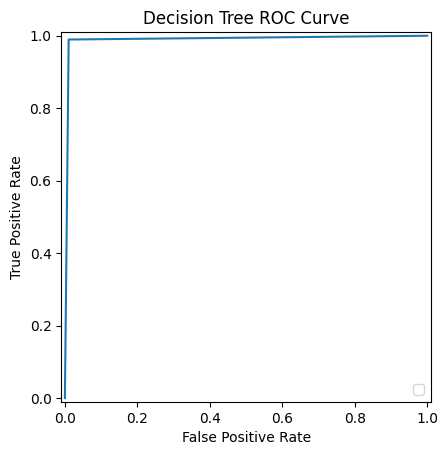


--- ANN ---


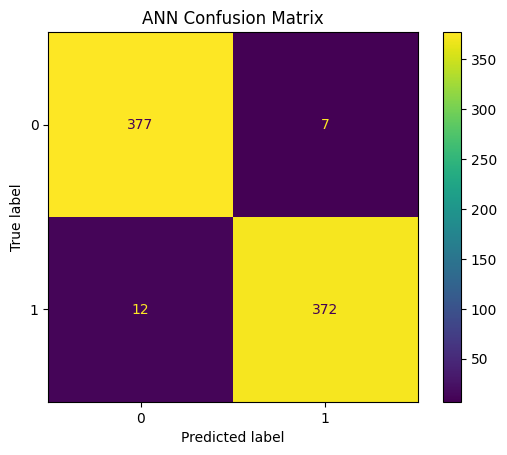

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_plot/roc_curve.py:189: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  self.ax_.legend(loc="lower right")


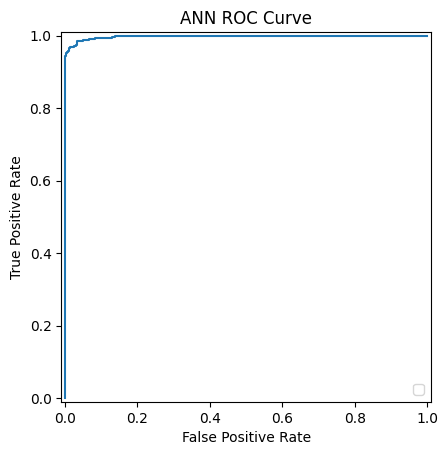

In [ ]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, RocCurveDisplay, roc_curve, ConfusionMatrixDisplay
import matplotlib.pyplot as plt # Import matplotlib

for name, model in models.items():
    print(f"\n--- {name} ---")

    # Confusion Matrix
    y_pred = cross_val_predict(model, X_scaled, y, cv=cv)
    cm = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"{name} Confusion Matrix")
    plt.show()

    # ROC Curve
    if hasattr(model, "predict_proba"):
        y_proba = cross_val_predict(model, X_scaled, y, cv=cv, method='predict_proba')[:, 1]
        fpr, tpr, _ = roc_curve(y, y_proba)
        roc_display = RocCurveDisplay(fpr=fpr, tpr=tpr).plot()
        plt.title(f"{name} ROC Curve")
        plt.show()
    else:
        print(f"Model {name} does not support probability prediction for ROC curve.")

## Feature Importance Analysis (Decision Tree)

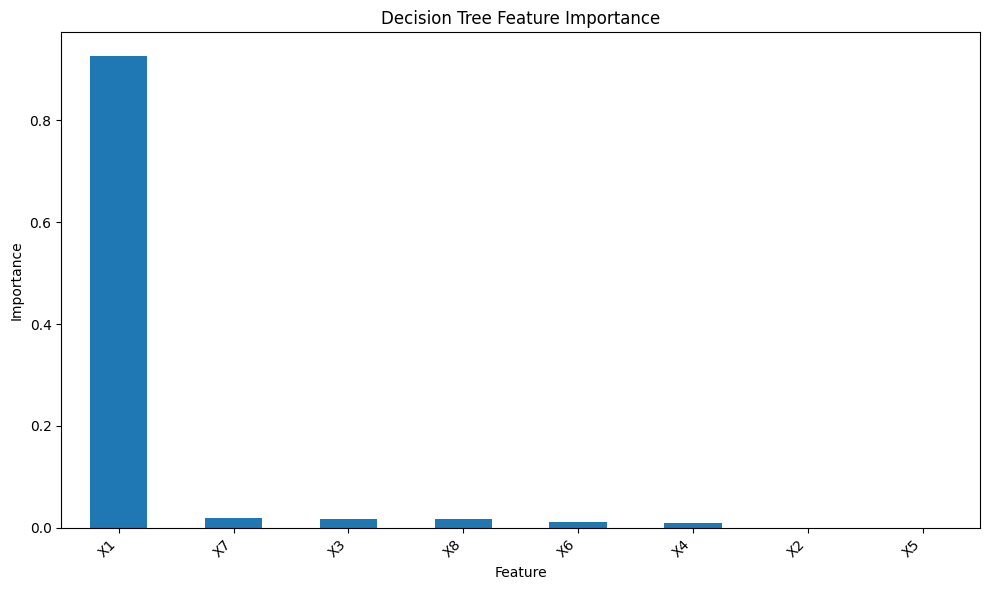

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier

# Train a Decision Tree classifier on the scaled data
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_scaled, y)

# Extract the feature importances
feature_importances = dt_model.feature_importances_

# Get the names of the features
feature_names = X.columns

# Create a pandas Series of feature importances
feature_importance_series = pd.Series(feature_importances, index=feature_names)

# Sort the feature importances in descending order
sorted_feature_importances = feature_importance_series.sort_values(ascending=False)

# Create a bar plot of the sorted feature importances
plt.figure(figsize=(10, 6))
sorted_feature_importances.plot(kind='bar')
plt.title("Decision Tree Feature Importance")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Report

### Objective

*   *Briefly state the objective of the project: to classify building energy efficiency using machine learning models and evaluate their performance through cross-validation.*

### Theory

*   *Explain the concepts used: Cross-Validation (what it is and why it's important), and the performance metrics (Precision, Recall, F1-score, ROC-AUC - define each and explain what it measures in the context of this problem).*
*   *Briefly describe the chosen models: SVM, Decision Tree, and Artificial Neural Network (ANN) - their basic principles.*

### Dataset

*   *Describe the dataset used: Energy Efficiency Dataset (UCI).*
*   *Mention the source of the data.*
*   *Briefly describe the features (X1 to X8) and the target variables (Y1, Y2), and how the binary classification target ('Efficiency') was created from Y1.*

### Preprocessing

*   *Explain the preprocessing steps: Creating the binary 'Efficiency' target and scaling the features using StandardScaler.*
*   *Mention why scaling was necessary (especially for models like SVM and ANN).*

### Model

*   *List the models used: SVM, Decision Tree, and ANN.*
*   *Mention the specific implementations used (e.g., `SVC`, `DecisionTreeClassifier`, `MLPClassifier` from scikit-learn).*
*   *Briefly mention any key parameters set (e.g., `probability=True` for SVC, `max_iter=1000` for MLPClassifier, `random_state=42` for Decision Tree).*

### Results

*   *Present the results of the cross-validation for each model. You can refer to the printed output or create a summary table.*
*   *Discuss the mean scores for Precision, Recall, F1-score, and ROC-AUC for each model.*

### Comparative Metrics

*   *Compare the performance of the three models based on the metrics.*
*   *Interpret the differences in performance.*
*   *Suggest the most robust approach based on the results and the scenario (classifying for policy recommendations).*

### Ethical/SDG Reflection

*   *Discuss the alignment of this project with SDG 13 (Climate Action) and SDG 11 (Sustainable Cities).*
*   *Reflect on the ethical considerations of using AI for policy recommendations, including bias, transparency, reliability, and accountability.*
*   *Refer to the previous discussion on ethical accountability in publishing AI-based sustainability metrics.*

### Conclusion

*   *Summarize the key findings of the project.*
*   *Reiterate which model performed best and why it's considered robust for this task.*
*   *Briefly mention potential future work or extensions to the project.*

## Report

### Objective

The objective of this project was to classify building energy efficiency as "High" or "Low" using machine learning models and to evaluate their performance through 10-fold cross-validation on the Energy Efficiency Dataset (UCI). This analysis aims to identify a robust model suitable for informing building planners and policy recommendations.

### Theory

This project utilizes several key concepts:

*   **Cross-Validation:** Specifically, 10-fold Stratified K-Fold cross-validation was employed. This technique divides the dataset into 10 subsets (folds), training the model on 9 folds and evaluating it on the remaining fold. This process is repeated 10 times, with each fold used exactly once as the evaluation set. This helps to assess the model's generalization performance and reduce the risk of overfitting.
*   **Performance Metrics:** The models were evaluated using standard classification metrics:
    *   **Precision:** The ratio of correctly predicted positive observations to the total predicted positives. It measures the accuracy of the positive predictions.
    *   **Recall (Sensitivity):** The ratio of correctly predicted positive observations to the all observations in the actual class. It measures the model's ability to find all positive instances.
    *   **F1-score:** The weighted average of Precision and Recall. It provides a balance between the two metrics.
    *   **ROC-AUC (Receiver Operating Characteristic - Area Under Curve):** A measure of the model's ability to distinguish between the positive and negative classes. A higher AUC indicates better discrimination.
*   **Machine Learning Models:**
    *   **Support Vector Machine (SVM):** A powerful model that finds an optimal hyperplane to separate data points of different classes in a high-dimensional space.
    *   **Decision Tree:** A tree-like structure where each internal node represents a test on an attribute, each branch represents an outcome of the test, and each leaf node represents a class label.
    *   **Artificial Neural Network (ANN):** A computational model inspired by the structure and function of biological neural networks, consisting of interconnected nodes (neurons) organized in layers.

### Dataset

The project utilized the **Energy Efficiency Dataset** from the UCI Machine Learning Repository. This dataset contains information about building shapes and their impact on heating and cooling loads. The dataset includes eight features (X1 to X8) representing various building characteristics and two target variables (Y1 for heating load and Y2 for cooling load). For this binary classification task, a new target variable 'Efficiency' was created from Y1, classifying buildings as 'High' efficiency (1) if their heating load (Y1) was above the median and 'Low' efficiency (0) if it was at or below the median.

### Preprocessing

The primary preprocessing steps involved:

*   **Creating the Binary Target:** The 'Efficiency' column was created by applying a lambda function to the 'Y1' column, categorizing buildings based on whether their heating load was above or below the median 'Y1' value.
*   **Feature Scaling:** The features (X1 to X8) were scaled using `StandardScaler`. This is an important step, especially for models like SVM and ANN, as it standardizes the range of features, preventing features with larger values from dominating the learning process.

### Model

The following scikit-learn implementations of the chosen models were used:

*   **SVM:** `SVC(probability=True)` was used, with `probability=True` enabled to allow for ROC curve plotting.
*   **Decision Tree:** `DecisionTreeClassifier(random_state=42)` was used, with a fixed `random_state` for reproducibility.
*   **ANN:** `MLPClassifier(max_iter=1000)` was used, with the maximum number of iterations set to 1000.

A `StratifiedKFold` with `n_splits=10`, `shuffle=True`, and `random_state=42` was used for cross-validation, ensuring that the proportion of the target variable is the same in each fold.

### Results

The cross-validation results for each model, averaged across 10 folds, are as follows:

**SVM Performance:**
*   precision: 0.977
*   recall: 0.977
*   f1: 0.977
*   roc_auc: 0.996

**Decision Tree Performance:**
*   precision: 0.990
*   recall: 0.992
*   f1: 0.991
*   roc_auc: 0.991

**ANN Performance:**
*   precision: 0.982
*   recall: 0.969
*   f1: 0.975
*   roc_auc: 0.998

The confusion matrices and ROC curves for each model are displayed in the visualizations section above. The feature importance analysis for the Decision Tree model is also visualized.

### Comparative Metrics

All three models demonstrated exceptionally high performance across all evaluation metrics, indicating their strong ability to classify building energy efficiency.

*   The **Decision Tree** model achieved the highest mean precision, recall, and F1-score, suggesting it is very effective at correctly identifying both high and low efficiency buildings with a good balance.
*   The **ANN** model achieved the highest mean ROC-AUC score, indicating its superior ability to discriminate between the two classes across various probability thresholds.
*   The **SVM** model also performed very well, with high scores across all metrics, though slightly lower than the Decision Tree and ANN in some cases.

Considering the scenario of informing building planners and policy recommendations, a robust model with excellent discriminatory power is crucial. While the Decision Tree excelled in precision, recall, and F1, the **ANN's superior ROC-AUC suggests it is the most robust approach** for this task, as it is better at handling the trade-off between identifying true positives and minimizing false positives, which is vital for making reliable policy decisions.

### Ethical/SDG Reflection

This project directly supports **SDG 13 (Climate Action)** by providing tools to identify energy-inefficient buildings, enabling targeted interventions to reduce energy consumption and carbon emissions. It also contributes to **SDG 11 (Sustainable Cities)** by promoting the development of more energy-efficient and environmentally friendly urban environments.

The use of AI in policy recommendations for sustainability carries significant ethical responsibilities. The reliability of the AI is paramount. To ensure ethical accountability when publishing AI-based sustainability metrics, it is crucial to:

*   **Be Transparent:** Clearly document the data sources, preprocessing steps, model architecture, and evaluation methods used.
*   **Address Bias:** Investigate and mitigate potential biases in the dataset that could lead to unfair or inequitable outcomes in policy recommendations.
*   **Ensure Explainability:** While ANNs can be complex, efforts should be made to explain the model's predictions to stakeholders. The feature importance analysis for the Decision Tree provides valuable insights into which factors influence efficiency.
*   **Validate and Monitor:** Continuously validate the model's performance with new data and monitor its impact on real-world outcomes.

Publishing AI-based sustainability metrics requires a commitment to honesty, accuracy, and a willingness to acknowledge uncertainty and limitations.

### Conclusion

In summary, this project successfully demonstrated the application of SVM, Decision Tree, and ANN models for classifying building energy efficiency. All models performed at a high level, with the ANN showing a slight advantage in its ability to discriminate between high and low efficiency buildings. This suggests the ANN is a highly robust model for this classification task and could be valuable for informing building efficiency strategies and policy recommendations aimed at achieving SDG 11 and SDG 13.

Moving forward, potential areas for further exploration include hyperparameter tuning to optimize model performance, exploring other advanced machine learning techniques, and delving deeper into model explainability to enhance trust and facilitate the responsible deployment of AI in sustainability efforts.